# OKAFF: mean shift $\mu=-3$, $d=1$

Plot for $m=500$, $1000$, and $5000$: logarithmic ARL and linear EDD.


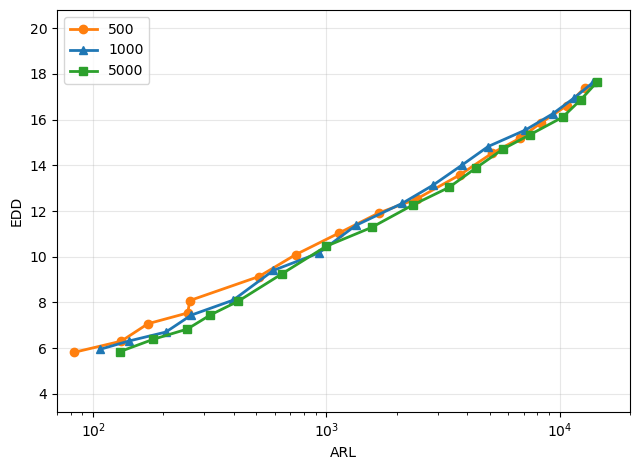

Saved okaff_mean03_edd-d1.pdf


In [ ]:
"""Plot OKAFF EDD versus ARL for the mean-shift case (mu = -3), d = 1.
"""

from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import LogFormatterMathtext, MaxNLocator
import pandas as pd

CASE_NAME = "MeanShift(mu=-3)"
FEATURE_COUNTS = (500, 1000, 5000)
STYLES = {
    500: {"marker": "o", "color": "#ff7f0e"},
    1000: {"marker": "^", "color": "#1f77b4"},
    5000: {"marker": "s", "color": "#2ca02c"},
}
OUTPUT_PDF = "okaff_mean03_edd-d1.pdf"


def find_csv(feature_count: int) -> Path:
    filename = (
        f"OKAFF-ARL-EDD-d1-m{features}-nrun{n_runs}.csv"
    )
    candidates = (Path(filename), Path("AFF") / filename)
    for path in candidates:
        if path.is_file():
            return path
    raise FileNotFoundError(
        f"Could not find {filename}; checked: "
        + ", ".join(str(path) for path in candidates)
    )


def load_case(path: Path) -> pd.DataFrame:
    data = pd.read_csv(path).rename(
        columns={"arl_hat_method3": "arl_hat", "edd_hat_method3": "edd_hat"}
    )
    case = data.loc[data["post_change_name"] == CASE_NAME].sort_values("arl_hat")
    if case.empty:
        raise ValueError(f"{CASE_NAME} was not found in {path.name}")
    return case


def make_y_ticks(values: list[float]) -> list[float]:
    locator = MaxNLocator(nbins=7, integer=True, min_n_ticks=5)
    return [
        float(tick)
        for tick in locator.tick_values(min(values), max(values) * 1.08)
        if tick > 0
    ]


def main() -> None:
    fig, ax = plt.subplots(figsize=(6.5, 4.8))
    edd_values: list[float] = []

    for m in FEATURE_COUNTS:
        case = load_case(find_csv(m))
        edd_values.extend(case["edd_hat"].dropna().tolist())
        ax.plot(
            case["arl_hat"],
            case["edd_hat"],
            marker=STYLES[m]["marker"],
            color=STYLES[m]["color"],
            linewidth=2,
            label=f"{m}",
        )

    ax.set_xscale("log")
    ax.set_xlim(70, 20000)
    ax.set_xticks([1e2, 1e3, 1e4])
    ax.xaxis.set_major_formatter(LogFormatterMathtext(base=10))

    ax.set_yscale("linear")
    y_ticks = make_y_ticks(edd_values)
    ax.set_yticks(y_ticks)
    ax.set_yticklabels([f"{tick:g}" for tick in y_ticks])
    y_min = min(min(edd_values), min(y_ticks))
    y_max = max(max(edd_values), max(y_ticks))
    padding = 0.05 * max(y_max - y_min, 1)
    ax.set_ylim(y_min - padding, y_max + padding)

    ax.set_xlabel("ARL")
    ax.set_ylabel("EDD")
    ax.grid(True, alpha=0.3)
    ax.legend()

    fig.tight_layout()
    fig.savefig(OUTPUT_PDF, bbox_inches="tight")
    plt.show()
    print(f"Saved {OUTPUT_PDF}")


if __name__ == "__main__":
    main()
